# 4. GPT 모델 구현

## 4.1. LLM 구조 구현

#### GPT 같은 LLM
    - 한 번에 하나의 단어(토큰)씩 새로운 텍스트를 생성하도록 고안됨
    - 많은 구성 요소가 반복되기 때문에 구조 자체는 엄청나게 복잡하지 않음
    - 트랜스포머 블록 : masked multihead-attention module 구현

#### GPT-2 모델의 임베딩 크기로 늘리기 (124M 파라미터)
* 파라미터: 훈련 가능한 가중치 의미

#### GPT-2 모델 설정
* vocab_size: BPE 토크나이저에서 사용할 50,257 토큰으로 구성된 어휘사전 크기를 나타냄
* context_length: 위치 임베딩으로 모델이 다룰 수 있는 입력 토큰의 최대 개수
* emb_dim: 임베딩 크기 (각 토큰을 768차원의 벡터로 변환)
* n_heads: 멀티 헤드 어텐션 메커니즘에 있는 어텐션 헤드 개수
* n_layers: 모델에 있는 트랜스포머 블록 개수 지정
* drop_rate: 과대적합을 막기 위한 드롭아웃 메커니즘의 강도를 지정 (0.1은 은닉 유닛의 10%를 랜덤으로 제외한다는 뜻)
* qkv_bias: 멀티 헤드 어텐션의 Linear 층에서 쿼리, 키, 값을 계산할 때 편향 유닛을 도입할지 여부 결정
    - 현대적인 LLM 구성방식을 따라 처음에는 이 값을 비활성화함.

In [ ]:
GPT_CONFIG_124M = {
    "vocab_size": 50257,     # 어휘사전 크기
    "context_length": 1024,  # 문맥 길이
    "emb_dim": 768,          # 임베딩 차원
    "n_heads": 12,           # 어텐션 헤드 개수
    "n_layers": 12,          # 층 개수
    "drop_rate": 0.1,        # 드롭아웃 비율
    "qkv_bias": False        # 쿼리, 키, 값 계산을 위한 편향
}

#### GPT 더미 클래스 (DummyGPTModel) : GPT Backbone
* pytorch의 nn.module을 사용해 간소화된 GPT 모델 정의
* token embedding + positional embedding + dropout + transformer blocks + layer norm (정규화) + 선형 출력 층


In [ ]:
import torch

import torch.nn as nn

class DummyGPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        # 더미 트랜스포머 블록 사용
        self.trf_blocks = nn.Sequential(
            *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
        self.final_norm = DummyLayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    # 모델을 통과하는 데이터 흐름 기술
    # 입력 인덱스를 위한 토큰 임베딩과 위치 임베딩 계산 + 드롭아웃 적용 + 트랜스포머 블록으로 데이터 처리
    # + 최종 층 정규화 + 선형 출력층으로 logit 생성
    # logit: 소프트맥스 함수 / 시그모이드 함수를 사용해 확률로 변환하기 전의 출력 값
    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(
            torch.arange(seq_len, device=in_idx.device)
        )
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits
    
# 나중에 실제 트랜스포머 블록으로 교체될 더미 클래스
class DummyTransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()

    # 아무것도 하지 않고 입력을 그냥 반환
    def forward(self, x):
        return x

# 층 정구화 인터페이스를 흉내내기 위한 매개변수
class DummyLayerNorm(nn.Module):
    def __init__(self, normalized_shape, eps=1e-5):
        super().__init__()

    def forward(self, x):
        return x

#### 입력 데이터 준비 + 새로운 GPT 모델 초기화 + 모델 사용법

#### tiktoken 토크나이저로 GPT 모델에 사용할 2개의 텍스트로 구성된 배치 토큰화

- 결과: tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

- 첫 번째 행: 첫 번째 텍스트에 해당
- 두 번째 행: 두 번쨰 텍스트에 해당


In [ ]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)

#### 124M DummyGPTModel 초기화 + 토큰화된 batch 주입

```
출력 크기: torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6754, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],
        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)
```

- 출력 크기: torch.Size([2, 4, 50257])
    - 2: 2개의 행 (2개의 텍스트 샘플)
    - 4: 각 텍스트 샘플이 4개의 토큰으로 구성됨
    - 50257: 각 토큰은 토크나이저 어휘사전의 크기에 해당하는 50,257 차원의 벡터임

In [ ]:
torch.manual_seed(123)
model = DummyGPTModel(GPT_CONFIG_124M)
logits = model(batch)
print("출력 크기:", logits.shape)
print(logits)

## 4.2. 층 정규화로 활성화 정규화
* 기울기 소실/폭주 문제 = 손실 함수를 최소화하는 신경망 파라미터 집합을 찾기 어렵다는 뜻

#### 층 정규화 (layer normalization)
* 신경망 훈련의 안정성과 효율성을 높임
* 핵심 아이디어
    - 신경망 층의 활성화(출력)를 평균이 0, 분산이 1이 되도록 조정함
    - 가중치의 수렴 속도를 높이며 일관되고 안정적인 훈련을 보장함
* 층 정규화가 멀티 헤드 어텐션 모듈 이전/이후, 최종 출력 층 이전에도 적용됨

In [ ]:
# 위 그림 코드 예시
# 5개의 입력과 6개의 출력을 가진 신경망 층에 2개의 입력 샘플 적용

torch.manual_seed(123)
batch_example = torch.randn(2, 5)  # 5개의 차원(특징)을 가진 2개의 샘플
layer = nn.Sequential(nn.Linear(5, 6), nn.ReLU())  # 5차원 입력을 6차원 출력으로 변환하는 층
out = layer(batch_example)
print(out)

In [ ]:
mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)
print("평균:", mean)
print("분산:", var) 

#### mean, var 연산의 keepdim, dim
* keepdim=True 사용 시
    - dim 매개변수에 지정된 차원을 따라 텐서가 축소되는 연산이더라도 출력 텐서의 차원이 입력 텐서와 동일하게 유지됨
* keepdim=False였다면?
    - mean 텐서: 2x1 차원 행렬 [[0.1324],[0.2170]]이 아닌 2차원 벡터 [0.1324, 0.2170]이 됐을 것
* dim
    - 텐서에서 통계 계산이 수행되어야 할 차원 지정
    - 2차원 텐서(행렬)의 경우 평균/분산 같은 연산에 dim=-1을 적용하는 건 dim=1을 적용하는 것과 같음
* 나중에 dim 사용 시
    - [batch_size, num_tokens, embedding_size] 크기의 3차원 텐서를 만드는 GPT 모델에 층 정규화를 추가할 때도 dim=-1을 사용해 마지막 차원에 대한 정규화 수행

In [ ]:
# 앞서 얻은 층 출력에 층 정규화적용
out_norm = (out - mean) / torch.sqrt(var)
mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)
print("정규화된 층 출력:", out_norm)
print("평균:", mean)
print("분산:", var)

In [ ]:
# 가독성을 위해 sci_mode=False로 설정하여 텐서 출력 시 과학적 표기 대신 일반 숫자 표기로 출력하도록 설정
torch.set_printoptions(sci_mode=False)
print(out_norm)
print(mean, '\n', var)

#### 층 정규화 클래스
* 입력 텐서 x의 마지막 차원인 임베딩 차원(emb_dim)에 대해 작동함
* eps: 정규화 시 0 나눗셈 방지를 위해 분산에 더해짐 (epsilon)
* scale, shift: 입력과 차원이 동일한 훈련 가능한 파라미터
    - 처리하는 데이터에 가장 잘 맞는 스케일 조정과 이동 학습

In [ ]:
class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

#### LayerNorm 모듈 배치에 적용

In [ ]:
ln = LayerNorm(emb_dim=5)
out_ln = ln(batch_example)
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, unbiased=False, keepdim=True)
print("평균: ", mean)
print("분산: ", var)

#### 지금까지 GPT 구조 구현에 필요한 구성 요소 중 2개를 다룸

## 4.3. GELU 활성화 함수를 사용하는 피드포워드 네트워크 구현

#### ReLU 대안
1. GELU(Gaussian error linear unit)
    * 가우시안 오차 함수를 사용한 더 복잡하고 부드러운 활성화 함수
2. SwiGLU(Swish-gated linear unit)
    * 시그모이드 GLU(gated linear unit)을 사용한더 복잡하고 부드러운 활성화 함수

#### GELU: 표준정규분포의 누적분포함수(CDF)
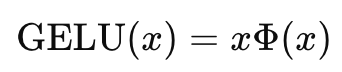

#### GELU 원본식
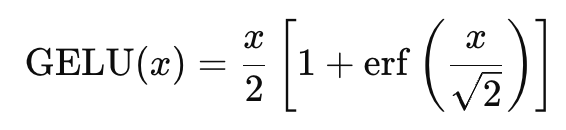
#### GELU 근사식
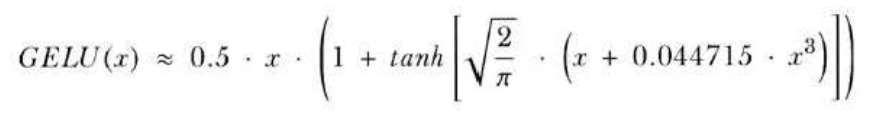

#### GELU 활성화 함수 구현

In [ ]:
class GELU(nn.Module):
    def __init__(self):
        super().__init__()
    
    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * torch.pow(x, 3))))

#### ReLU vs. GELU 시각화
* GELU는 모든 음수 값의 그래디언트를 0으로 만들지 않음
* 대략 x = -0.75에서는 그래디언트가 0

* GELU가 부드럽기 때문에 훈련 과정에서 최적화가 잘 되는 성질이 있음
    - 모델 파라미터를 미묘하게 조절 가능함
    - 음수 입력을 받는 뉴런도 적지만 학습 과정에 기여 가능함

In [ ]:
import matplotlib.pyplot as plt

gelu = GELU()
relu = nn.ReLU()

x = torch.linspace(-3, 3, 100) # -3에서 3까지 100개의 점을 생성하는 텐서
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
	plt.subplot(1, 2, i)
	plt.plot(x, y)
	plt.title(f"{label} activation function")
	plt.xlabel("x")
	plt.ylabel(f"{label}(x)")
	plt.grid(True)

plt.tight_layout()
plt.show()

#### FeedForward (트랜스포머 블록에 사용할 작은 신경망 모듈)
* 2개의 Linear층과 하나의 GELU 활성화 함수로 구성된 작은 신경망
* 124M 파라미터를 가진 GPT 모델의 경우 임베딩 크기가 768인 토큰으로 구성된 입력 배치를 받음
    - GPT_CONFIG_124M["emb_dim"] = 768

In [ ]:
class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
            GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"])
        )
    def forward(self, x):
        return self.layers(x)

#### 토큰 임베딩 크기를 768로 하여 FeedForward 모듈 초기화
* 출력 텐서 크기가 입력 텐서와 같은 것을 확인할 수 있음

In [ ]:
ffn = FeedForward(GPT_CONFIG_124M)
x = torch.rand(2, 3, 768) # 2개의 샘플, 토큰 길이 3, 임베딩 차원 768
out = ffn(x)
print("출력 크기:", out.shape)

#### FeedForward 모듈
* 데이터 학습 및 일반화 능력 향상에 있어 매우 중요함
* 입력 차원과 출력 차원이 같지만 내부적으로 첫 번째 선형 층에서 임베딩 차원을 고차원 공간으로 확장함
* 확장한 후 비선형 GELU 함수가 뒤따르고 두 번째 선형 변환을 통해 원본 차원으로 수축
* 이런 구조를 통해 풍부한 표현 공간 탐색 가능
* 입력/출력 차원이 같기 때문에 단순한 구조를 유지하며 여러 층을 쌓을 수 있음
    -> 층 사이에서 차원 조절 필요 x (모델 확장성이 뛰어남)

## 4.4. 숏컷 연결 추가하기
* 숏컷(shortcut) 연결 = 스킵(skip) 연결 = 잔차(residual) 연결
* 원래는 CV분야의 심층 신경망 (구체적으로는 residual network)에서 기울기 소실 문제를 완화하기 위해 제안됨

* 그래디언트가 1개 이상의 층을 건너뛰어 네트워크에 흐를 수 있도록 짧은 다른 경로를 만듦
* 이런 경로는 한 층의 출력을 이후 층의 출력에 더함으로써 만들어짐

#### 숏컷 연결 설명을 위한 신경망

In [ ]:
class ExampleDeepNeuralNetwork(nn.Module):
    def __init__(self, layer_sizes, use_shortcut):
        super().__init__()
        self.use_shortcut = use_shortcut
        self.layers = nn.ModuleList([ # 5개의 층을 만듦
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU())
        ])

    def forward(self, x):
        for layer in self.layers:
            layer_output = layer(x) # 현재 층의 출력 계산
            if self.use_shortcut and x.shape == layer_output.shape: # 숏컷 연결을 적용할 수 있는지 확인
                x = x + layer_output
            else:
                x = layer_output
        return x

#### 숏컷 연결이 없는 신경망 초기화 + 모델의 역전파에서 그래디언트를 계산하는 함수 구현
* 각 층은 3개의 입력 값을 가진 샘플을 받아 3개의 출력 값 반환
* 마지막 층은 하나의 값을 반환

* print_gradients 함수를 숏컷 연결이 없는 모델에 적용 
    - 마지막층에서 첫번째 층으로 갈수록 그래디언트가 점점 작아짐

In [ ]:
layer_sizes = [3, 3, 3, 3, 3, 1]
simple_input = torch.tensor([[1., 0., -1.]])
torch.manual_seed(123)
model_without_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=False)

In [ ]:
def print_gradients(model, x):
    output = model(x) # 정방향 계산
    target = torch.tensor([[0.]])

    loss = nn.MSELoss()
    loss = loss(output, target) # 타겟과 출력의 가까운 정도를 기반으로 손실 계산
    
    loss.backward() # 그래디언트 계산을 위한 역전파

    for name, param in model.named_parameters():
        if 'weight' in name:
            grad_mean = param.grad.abs().mean().item() if param.grad is not None else None
            print(f"{name}의 평균 그래디언트는 {grad_mean}입니다.")

print_gradients(model_with_shortcut, simple_input)

#### print_gradients 함수를 숏컷 연결이 있는 모델에 적용

In [ ]:
torch.manual_seed(123)
model_with_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=True)
print_gradients(model_with_shortcut, simple_input)

## 4.5. 어텐션과 선형 층을 트랜스포머 블록에 연결
* GPT-2 모델에서는 트랜스포머 블록이 12번 반복됨
    - 멀티 헤드 어텐션, 층 정규화, 드롭아웃, 피드 포워드 신경망, GELU 활성화 함수, 숏컷 연결 등을 복합적으로 사용함

* 트랜스포머 블록이 입력 시퀀스를 처리할 때 시퀀스에 있는 각 원소(단어 or 부분단어 토큰)는 고정 크기의 벡터(여기서는 768차원)로 표현됨
* 트랜스포머 블록 안의 연산은 이 벡터의 차원을 유지하면서 변환하도록 고안됨
    1. MultiheadAttention -> Self-Attention Mechanism
        : 입력 시퀀스에 있는 원소 사이의 관계 식별 + 분석
    2. FeedForward 
        : 각 위치의 데이터를 개별적으로 변환
        

#### 트랜스포머 블록을 위한 멀티헤드어텐션 클래스

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()

        assert d_out % num_heads == 0, "d_out은 num_heads로 나누어 떨어져야 합니다"

        self.d_out = d_out
        self.num_heads = num_heads
        # 원하는 출력 차원에 맞도록 투영 차원을 낮춤
        self.head_dim = d_out // num_heads

        # Query, Key, Value 선형 변환
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        # 여러 head의 출력을 다시 섞어주는 출력 projection
        # Linear층을 사용해 헤드의 출력을 결합
        self.out_proj = nn.Linear(d_out, d_out)

        self.dropout = nn.Dropout(dropout)

        # causal mask
        # 위쪽 삼각행렬을 1로 만들어서 미래 토큰을 보지 못하게 함
        self.register_buffer(
            "mask",
            torch.triu(
                torch.ones(context_length, context_length),
                diagonal=1
            )
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        
        # 텐서 크기: (b, num_tokens, d_out)
        # x: (batch_size, num_tokens, d_in)
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        # num_heads 차원을 추가함으로써 암묵적으로 행렬 분할
        # 그런 다음 마지막 차원을 num_heads에 맞춰 채움
        # keys, queries, values:
        # (b, num_tokens, d_out)
        # -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)


        # head 차원을 앞으로 이동
        # (b, num_tokens, num_heads, head_dim)
        # -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # attention score 계산
        # queries: (b, num_heads, num_tokens, head_dim)
        # keys.transpose(2, 3): (b, num_heads, head_dim, num_tokens)
        # 결과: (b, num_heads, num_tokens, num_tokens)
        attn_scores = queries @ keys.transpose(2, 3)

        # 현재 토큰 수에 맞게 mask 자르기
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # 미래 토큰 위치를 -inf로 채움
        # 마스크를 사용해 어텐션 점수를 채움
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        # scaled dot-product attention
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1] ** 0.5,
            dim=-1
        )

        attn_weights = self.dropout(attn_weights)

        # attention weight와 value 곱하기
        # attn_weights: (b, num_heads, num_tokens, num_tokens)
        # values:       (b, num_heads, num_tokens, head_dim)
        # 결과:          (b, num_heads, num_tokens, head_dim)
        context_vec = attn_weights @ values

        # 다시 head 차원을 뒤로 보냄
        # 텐서 크기: (b, num_heads, num_tokens, head_dim) -> (b, num_tokens, num_heads, head_dim)
        context_vec = context_vec.transpose(1, 2)

        # 여러 head를 하나로 결합
        # (b, num_tokens, num_heads, head_dim)
        # -> (b, num_tokens, d_out)
        context_vec = context_vec.contiguous().view(
            b, num_tokens, self.d_out
        )

        # 마지막 출력 projection (선형 투영)
        context_vec = self.out_proj(context_vec)

        return context_vec

#### GPT의 트랜스포머 블록
* 멀티 헤드 어텐션 + 피드 포워드 신경망 포함
* GPT_CONFIG_124M과 같은 설정 딕셔너리(cfg) 기반

* 층 정규화는 두 구성 요소 전에 적용 (사전 층 정규화)
* 드롭아웃은 모델을 규제+과대적합 방지용이므로 두 구성 요소 후에 적용

* 예전 구조에서는 셀프 어텐션/피드 포워드 신경망 후에 층 정규화 적용 (사후 층 정규화)

In [ ]:
# 이 클래스는 정방향 계산도 구현함
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        shortcut = x # 어텐션 블록을 위한 숏컷 연결
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut # 원본 입력을 더함

        shortcut = x # 피드포워드 신경망을 위한 숏컷 연결
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut # 원본 입력을 더함

        return x

#### 트랜스포머 블록이 입력 차원과 출력 차원을 동일하게 유지
* 이를 통해 출력 벡터가 입력 벡터에 일대일 관계로 직접 대응되는 다양한 seq-to-seq 작업에 효과적으로 적용 가능함
* 출력은 전체 입력 시퀀스의 정보를 담은 문맥 벡터 (출력 벡터의 내용은 전체 입력 시퀀스의 문맥 정보를 통합하도록 재인코딩됨)

In [ ]:
torch.manual_seed(123)
x = torch.rand(2, 4, 768) # [batch_size, num_tokens, emb_dim] 크기의 샘플 입력
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)

print("입력 크기:", x.shape)
print("출력 크기:", output.shape)

## 4.6. GPT 모델 만들기

#### 전체 구조
* 트랜스포머 블록은 GPT 모델 안에서 여러 번 반복됨 (GPT-2 124M는 12번 반복)
* GPT-2 1542M는 48번 반복
* 마지막 트랜스포머 블록의 출력이 최종 층 정규화와 선형 출력 층 통과
* 이 층은 트랜스포머 블록의 출력을 고차원 공간 (모델의 어휘사전 크기에 해당하는 50,257차원)에 매핑하여 시퀀스의 다음 토큰 예측

#### GPT 모델 구조 구현

* GTPModel 클래스의 __init__ 생성자
    - 파이썬 딕셔너리 cfg로 전달된 설정을 사용해 토큰 임베딩 층과 위치 임베딩 층 초기화
    - 임베딩 층: 입력 토큰 인덱스를 밀집 벡터로 변환 + 위치 정보를 추가하는 역할
* __init__ 메서드
    - cfg에 지정딘 층 개수만큼 transformer block 모듈의 sequential stack을 만듦
        > 트랜스포머 블록 다음에 훈련 과정 안정화를 위해 트랜스포머 블록의 출력을 정규화하는 LayerNorm층 정의

        > 마지막으로 트랜스포머 블록의 출력을 토크나이저의 어휘사전 공간에 투영하여 어휘사전에 있는 각 토큰에 대한 로짓을 생성하기 위해 편향이 없는 선형 출력 헤드 정의
* forward 메서드
    - 입력 토큰의 배치를 받아 임베딩 계산 + 위치 임베딩 적용 + 트랜스포머 블록 통과 + 최종 출력 계산 + 로짓 계산
        > 로짓은 다음 토큰에 대한 정규화되지 않은 확률

In [ ]:
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )
        self.final_norm = LayerNorm(cfg["emb_dim"])
        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        
        # 장치 설정을 통해 입력 데이터가 어디에 있는지에 따라 모델을 CPU나 GPU에서 훈련 가능
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

#### GPT_CONFIG_124M 딕셔너리를 cfg 매개변수에 전달
- GPT 모델 초기화 + 이전에 만든 배치 텍스트 입력 주입

- 4개의 토큰을 가진 2개의 입력 텍스트를 전달했기 때문에 출력 텐서 크기는 [2, 4, 50257]
    - 50257은 토크나이저 어휘사전 크기

- 결과
``` 
    입력 배치
        : tensor([[6109, 3626, 6100,  345], # 텍스트 1의 토큰 ID
                [6109, 1110, 6622,  257]])  # 텍스트 2의 토큰 ID
```


In [ ]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
out = model(batch)
print("입력 배치\n:", batch)
print("\n출력 크기: ", out.shape)
print("\n출력:\n", out)

In [ ]:
total_params = sum(p.numel() for p in model.parameters())
print(f"모델의 총 파라미터 수: {total_params}")

In [ ]:
trainable_params = sum(
    param.numel()
    for param in model.parameters()
    if param.requires_grad
)

print(f"학습 가능한 파라미터 수: {trainable_params:,}")

#### 모델의 총 파라미터 수: 163009536
* 124M이 아닌 163M인 이유
    - GPT-2 구조에 사용된 가중치 묶기 (weight tying)이라는 개념 때문임
        > 원본 GPT-2 구조는 토큰 임베딩 층의 가중치를 출력 층에 재사용함

* GPT Model로 초기화한 model 객체 안의 토큰 임베딩 층과 선형 출력 층의 크기 비교
    > 두 층의 가중치 텐서는 크기가 동일함

In [ ]:
print("토큰 임베딩 총 크기: ", model.tok_emb.weight.shape)
print("출력 총 크기: ", model.out_head.weight.shape)

#### 가중치 묶기를 사용한다고 가정하고 GPT-2 모델에서 출력 층의 가중치 제외

In [ ]:
total_params_gpt2 = (
    total_params - sum(p.numel()
    for p in model.out_head.parameters())
)
print(f"가중치 묶기를 고려한 훈련 가능한 파라미터 개수: {total_params_gpt2:,}")

In [ ]:
# 전체 파라미터 수 계산
total_params = sum(
    param.numel()
    for param in model.parameters()
)

print(f"전체 파라미터 수: {total_params:,}")


# token embedding과 output head의 파라미터 수 확인
token_embedding_params = model.tok_emb.weight.numel()
output_head_params = model.out_head.weight.numel()

print(f"Token Embedding 파라미터 수: {token_embedding_params:,}")
print(f"Output Head 파라미터 수: {output_head_params:,}")


# weight tying을 적용한다고 가정하면
params_with_weight_tying = total_params - output_head_params

print(f"Weight tying을 가정한 파라미터 수: {params_with_weight_tying:,}")

#### 가중치 묶기
* 전반적인 메모리 사용량과 모델의 복잡도를 줄임
    > 경험상 토큰 임베딩과 출력 층을 따로 두는 것이 훈련과 모델 성능에 더 좋음

#### GPTModel 객체에 있는 163M개 파라미터를 위한 메모리 공간 계산

* 모델에 필요한 메모리 공간: 621.83 MB
    - 작은 LLM이지만 필요한 저장 공간이 크다는 것을 보여줌

* 출력 텐서 크기
    - [batch_size, num_tokens, vocab_size]

In [ ]:
# 총 크기를 바이트 단위로 계산 (float32로 가정하면 파라미터당 4byte)
total_size_bytes = total_params * 4
total_size_mb = total_size_bytes / (1024 * 1024) # 메가바이트 단위로 변환

print(f"모델에 필요한 메모리 공간: {total_size_mb:.2f} MB")

## 4.7. 텍스트 생성하기
* LLM 같은 생성 모델이 한 번에 한 단어(토큰)씩 텍스트를 생성하는가

#### GPT 모델이 출력 텐서에서 텍스트를 생성하는 과정

* 출력 텐서 디코딩 + 확률 분포를 기반으로 토큰 선택 + 텍스트로 변환
1. 입력을 기반으로 다음 토큰을 생성하는 과정에서 모델은 가능성이 있는 다음 토큰을 표현하는 벡터를 담은 행렬 출력
2. 다음 토큰에 해당한느 벡터 추출 + softmax 함수를 사용해 확률분포로 변환
3. 확률 점수를 담은 벡터에서 가장 큰 값의 인덱스를 확인하여 토큰 ID로 해석
4. 토큰 ID를 텍스트로 디코딩하여 시퀀스의 다음 토큰으로 출력
5. 이 토큰을 이전 입력에 추가하여 이후 반복을 위한 새로운 입력 시퀀스를 만듦
6. 이를 사용자가 지정한 토큰 생성 횟수에 도달할 때까지 반복

#### GPT 모델로 텍스트를 생성하는 함수
* 지정한 토큰 생성 횟수 반복 + 모델의 최대 문맥 크기에 맞게 현재 문잭 잘라내기 + 예측 계산 + 확률 값 기반 다음 토큰 선택

* generate_text_simple 함수
    - softmax 함수를 사용해 로짓을 확률 분포로 바꾼 다음, torch.argmax로 가장 높은 값을 가진 위치 찾기
        > softmax 함수는 단조함수라서 입력의 크기 순서가 출력에 그대로 보존될
        > 즉 softmax 함수의 출력 텐서에서 가장 큰 값의 위치가 로짓 텐서에서 가장 큰 값의 위치와 동일함
        > 따라서 softmax 함수 적용 단계를 건너뛰고 로짓 텐서에 torch.argmax 함수를 바로 적용해도 동일한 결과가 나옴
    - 가장 가능성 있는 토큰을 샘플링 하는 greedy decoding 설명 가능

In [ ]:
def generate_text_simple(model, idx, # idx는 현재 문맥이 담긴 [batch_size, num_tokens] 크기의 인덱스 배열
                         max_new_tokens, context_size):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        
        logits = logits[:, -1, :] # 마지막 타임 스텝만 사용하므로 [batch_size, vocab_size]가 [batch_size, num_tokens, vocab_size]에서 [batch_size, vocab_size]로 축소됨
        probas = torch.softmax(logits, dim=-1) # probas는 [batch_size, vocab_size] 크기의 확률 분포
        idx_next = torch.argmax(probas, dim=-1, keepdim=True) # idx_next는 [batch_size, 1] 크기의 텐서로, 각 샘플에 대해 가장 높은 확률을 가진 다음 토큰의 인덱스
        idx = torch.cat((idx, idx_next), dim=1) # 선택한 인덱스를 현재 시퀀스에 추가하므로 idx의 크기는 [batch_size, num_tokens + 1]이 됨
    
    return idx

#### "Hello, I am" 문맥을 입력으로 사용해 generate_text_simple 함수를 테스트

##### 1. 입력 문맥을 토큰 ID로 인코딩

In [ ]:
start_context = "Every effort moves you"
encoded = tokenizer.encode(start_context)
print("인코딩된 ID:", encoded)
encoded_tensor = torch.tensor(encoded).unsqueeze(0) # 배치 차원 추가
print("\nencoded_tensor.shape:", encoded_tensor.shape)

##### 2. 모델을 .eval() 모드로 바꿈
* 훈련 과정에서만 사용되는 dropout 같은 확률적인 구성 요소를 끔
* 인코딩 된 입력 텐서로 generate_text_simple 함수 호출

In [ ]:
model.eval() # 모델을 평가 모드로 전환하여 드롭아웃과 같은 훈련 전용 동작을 비활성화
out = generate_text_simple(
    model = model, 
    idx = encoded_tensor, 
    max_new_tokens=6, 
    context_size=GPT_CONFIG_124M["context_length"]
)

print("출력: ", out)
print("출력 길이: ", out.shape[0])
print("생성 결과:", tokenizer.decode(out.squeeze(0).tolist()))

##### 3. 토크나이저의 .decode 메서드를 사용하여 ID를 텍스트로 변환
* 모델 훈련을 안 했기 때문에 일관성 있는 텍스트 생성에 실패
* 랜덤한 초기 가중치로 GPT 모델 객체만 만듦

In [ ]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print("디코딩된 텍스트: ", decoded_text)

## 4.8. 요약
* 층 정규화는 층의 출력이 일정한 평균과 분산을 갖도록 하여 훈련 안정화
* 숏컷 연결은 층의 출력을 1개 이상의 층을 건너뛰어 연결하는 기법
* LLM과 같이 심층 신경망을 훈련할 때 그래디언트 소실 문제 완화에 도움
* 트랜스포머 블록은 GPT 모델의 핵심 구성 요소
* 마스킹된 멀티 헤드 어텐션 모듈과 GELU 활성화 함수를 사용하는 완전 연결 피드포워드 신경망으로 구성
* GPT 모델은 트랜스포머 블록을 반복하여 만든 LLM
* 수백만 개에서 수십억 개의 파라미터 보유
* GPT 모델의 크기는 다양함
    - 예시로 1억 2,400만 개와 15억 4,200만 개의 파라미터를 가진 버전 존재
* 두 버전 모두 GPTModel 파이썬 클래스로 구현 가능
* GPT와 같은 LLM의 텍스트 생성 방식은 출력 텐서를 사람이 읽을 수 있는 텍스트로 디코딩하는 것
* 주어진 입력 문맥을 기반으로 한 번에 하나의 토큰씩 순차적으로 예측
* 훈련하지 않은 GPT 모델은 일관성 없는 텍스트 생성
* 일관된 텍스트 생성을 위해 모델 훈련이 중요함